# 第4讲 初识机器学习

## 本讲大纲

- [4.1 Scikit-Learn 与机器学习工具](#sec4_1)
  - [4.1.1 Scikit-Learn 概述](#sec4_1_1)
  - [4.1.2 项目起源与发展](#sec4_1_2)
  - [4.1.3 四大算法类别](#sec4_1_3)
  - [4.1.4 安装配置](#sec4_1_4)
- [4.2 有监督学习 —— 分类器与鸢尾花识别](#sec4_2)
  - [鸢尾花数据集初识](#sec4_2_1)
  - [数据准备（特征选取/分解/标准化/可视化）](#sec4_2_2)
  - [基于 SGD 的分类识别训练](#sec4_2_3)
  - [预测新数据](#sec4_2_4)
  - [检验模型效果（准确率/混淆矩阵）](#sec4_2_5)
  - [K-折交叉检验与 Pipeline](#sec4_2_6)
- [4.3 实战练习](#sec4_3)
  - [乳腺癌分类](#sec4_3_1)
  - [葡萄酒分类](#sec4_3_2)
- [4.4 拓展：TensorFlow 实现鸢尾花 SGD 分类](#sec4_4)
  - [4.4.1 认识 TensorFlow](#sec4_4_1)
  - [4.4.2 数据准备](#sec4_4_2)
  - [4.4.3 构建模型并训练](#sec4_4_3)
  - [4.4.4 观察：batch_size 对梯度下降的影响](#sec4_4_4)

# 4.1 初识 Scikit-Learn 与机器学习


- 官网 [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)


- 最新发布
    - 稳定版 scikit-learn 1.72
    - 开发版 Scikit-learn 1.8

### 机器学习工具

#### 七大机器学习工具对比

| 工具 | 开发者 | 核心优势 | 适用场景 | 活跃度 | GitHub |
|------|--------|----------|----------|--------|--------|
| **Shogun** | 社区开源 | 大规模SVM核方法，C++高性能 | 传统ML研究 | ⭐⭐ | [链接](https://github.com/shogun-toolbox/shogun) |
| **Keras** | Google | 简洁API，快速原型开发 | 深度学习入门 | ⭐⭐⭐⭐⭐ | [链接](https://github.com/keras-team/keras) |
| **scikit-learn** | 社区开源 | 统一API，算法丰富，文档完善 | 数据挖掘/分析 | ⭐⭐⭐⭐⭐ | [链接](https://github.com/scikit-learn/scikit-learn) |
| **Pattern** | CLiPS | Web挖掘+NLP一站式 | 文本/网络分析 | ⭐ | [链接](https://github.com/clips/pattern) |
| **Theano** | UMontreal | 符号计算，GPU加速，先驱 | 深度学习（已停更） | ⭐ | [链接](https://github.com/Theano/Theano) |
| **PyTorch** | Meta (FAIR) | 动态计算图，Debug友好 | 深度学习研究 | ⭐⭐⭐⭐⭐ | [链接](https://github.com/pytorch/pytorch) |
| **TensorFlow** | Google | 工业级部署，跨平台 | 生产环境 | ⭐⭐⭐⭐⭐ | [链接](https://github.com/tensorflow/tensorflow) |

> 💡 **本课程选用 scikit-learn**：最适合机器学习的初学者，API简洁统一，无需GPU，覆盖分类/回归/聚类/降维全部基础算法。

## 4.1.1 Scikit-Learn 概述

Scikit-Learn（简称 sklearn）是 Python 生态中最流行的机器学习库。它构建在 NumPy、SciPy、Matplotlib 之上，提供六大类功能的统一 API：

```mermaid
mindmap
  root((scikit-learn))
    分类 Classification
      SVM
      SGD
      KNN
      决策树
      随机森林
    回归 Regression
      SVR
      岭回归
      Lasso
    聚类 Clustering
      K-Means
      DBSCAN
      高斯混合
    降维 Dimensionality Reduction
      PCA
      t-SNE
    模型选择 Model Selection
      交叉验证
      网格搜索
    数据预处理 Preprocessing
      标准化
      归一化
```

### 4.1.2 🏛️ 项目起源与发展

| 时间 | 里程碑 |
|------|--------|
| **2007** | Google Summer of Code 项目立项，David Cournapeau 发起 |
| **2010** | INRIA 团队接手，Fabian Pedregosa 等人主导 |
| **2011** | 发表 JMLR 论文，正式成为学术级工具 |
| **2015** | 1.0 版本，成为 <a href="https://www.kaggle.com/"> Kaggle </a> 竞赛标配 |
| **至今** | 持续更新，最新稳定版 1.9+ |

<img src="images/ch12/David _Cournapeau.jpg" width=150>  
*发起人 David Cournapeau*

### ✨ 八大核心特点

| 特点 | 说明 |
|------|------|
| 🐍 **Python 原生** | 与 NumPy/Scipy/Pandas 无缝衔接 |
| 📚 **算法齐全** | 分类、回归、聚类、降维，持续更新 |
| 🎯 **中等规模** | 最适合 10²~10⁵ 样本级别的任务 |
| 👶 **新手友好** | 统一 API（fit / predict / transform），文档完善 |
| 📦 **最小依赖** | 仅需 NumPy + SciPy，轻量级 |
| 📜 **BSD 协议** | 商业友好，非 GPL 传染式协议 |
| 🆓 **完全免费** | 源码、文档、二进制均可自由下载 |
| 🌐 **中文支持** | [sklearn.apachecn.org](https://sklearn.apachecn.org/docs/0.21.3/51.html) |

### 4.1.3 🧭 四大算法类别速览

<img src='images\ch12\ch12-01.png'>

## 4.1.4 Scikit-Learn 的安装配置

- 推荐 Anaconda 环境下安装（略）

- 检查是否安装成功？
    - 以下代码应能正常运行，并显示版本号 1.3.0

In [3]:
#import sklearn as sk
import sklearn as sk
print ('scikit-learn version:', sk.__version__)

scikit-learn version: 1.7.2


- 导入配套使用的模块

In [4]:
%pylab inline

import IPython
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import sklearn

print ('IPython version:', IPython.__version__)
print ('numpy version:', np.__version__)
print ('matplotlib version:', matplotlib.__version__)
print('sklearn version:',sklearn.__version__)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
IPython version: 9.7.0
numpy version: 2.3.5
matplotlib version: 3.10.6
sklearn version: 1.7.2


## 4.2 有监督学习——分类器与鸢尾花识别


### 4.2.1 分类器问题

### 鸢尾花（iris）的分类问题


- 鸢尾花图片
<img src="images/ch13/iris_flower.jpg" width =300>


- 考虑训练数据集（含 $n$ 条样本，或记录）
    - 每条样本中，有多个数据，这些数据称之为属性（attribute）或特征（feature）
    - 如果是有监督学习，还要有目标（target）属性


- 数据集
    - 在 dataset 子模块中
    
    
<img src="images/ch13/flower.jpg" width =300>

### 数据的初期认识

#### (1) 加载数据

In [5]:
import sklearn
#dir(sklearn)
from sklearn import datasets
# 加载并返回 iris 数据集
iris = datasets.load_iris() # 位于 root_path\pkgs\scikit-learn-0.19.2-py37heebcf9a_0\Lib\site-packages\sklearn\datasets\data
#dir(datasets)
#datasets.load_iris?
iris


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

#### 普及一下datasets数据集
##### sklearn 的数据集有好多个种

- 自带的小数据集（packaged dataset）：sklearn.datasets.load_<name>  
    - 数据集文件在sklearn安装目录下datasets\data文件下
- 可在线下载的数据集（Downloaded Dataset）：sklearn.datasets.fetch_<name>  
    - 比较大的数据集，主要用于测试解决实际问题，支持在线下载
    - 下载下来的数据，默认保存在~/scikit_learn_data文件夹下，可以通过设置环境变量SCIKIT_LEARN_DATA修改路径，datasets.get_data_home()获取下载路径
- 计算机生成的数据集（Generated Dataset）：sklearn.datasets.make_<name>  
    - 构造数据集
- svmlight/libsvm格式的数据集：sklearn.datasets.load_svmlight_file(...)  
- 从买了data.org在线下载获取的数据集：sklearn.datasets.fetch_mldata(...)

#### 自带的小数据集有哪些？
- datasets.load_boston #波士顿房价数据集  
- datasets.load_breast_cancer #乳腺癌数据集  
- datasets.load_diabetes #糖尿病数据集  
- datasets.load_digits #手写体数字数据集  
- datasets.load_files  
- datasets.load_iris #鸢尾花数据集  
- datasets.load_lfw_pairs  
- datasets.load_lfw_people  
- datasets.load_linnerud #体能训练数据集  
- datasets.load_mlcomp  
- datasets.load_sample_image  
- datasets.load_sample_images  
- datasets.load_svmlight_file  
- datasets.load_svmlight_files  

#### (2) 了解一下数据结构

In [6]:
#iris.<TAB>
iris
#iris.
iris.keys()   # 字典关键字


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

- 认识几个不常见的单词 —— 关于 鸢尾花的特征属性
    - sepal 萼片
    - petal 花瓣

In [7]:
iris.feature_names
iris.data  # 4 列依次是 萼片长度、萼片宽度、花瓣长度、花瓣宽度，单位：厘米
iris.target_names


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

- 认识几个不常见的单词 —— 关于分类
    - setosa 山鸢尾花
    - versicolor 变色鸢尾花
    - virginica 维吉尼亚鸢尾花

- 认识三种鸢尾花 —— 从左至右分别是：'setosa'、'versicolor'、'virginica'


<img src="images/ch13/setosa_versicolor_virginica.jpg" width=800>

In [8]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

- iris 数据集的介绍

In [9]:
iris.DESCR # DESCR 属性

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [10]:
print(iris.DESCR)  # 格式输出

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

#### (3) 鸢尾花数据集 (Iris Datasets) 小结


- 基本信息
    - 数据记录 —— 150 条
    - 特征属性 —— 4 条（'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'）
    - 目标属性 —— 1 条（calss）


- 统计数据
    - 表明花瓣的 长度和宽度 与 类别的相关性高，分别达到 0.9490 和 0.9565

### 4.2.2 数据准备 —— 用于训练与测试

### 导入特征数据、目标数据

In [11]:
# 导入 特征与目标 数据
X_iris, y_iris = iris.data, iris.target

In [12]:
# 查看维度
print(X_iris.shape, y_iris.shape)
# 输出首行

X_iris[0], y_iris[0]


(150, 4) (150,)


(array([5.1, 3.5, 1.4, 0.2]), np.int64(0))

### 选取部分特征


- 提取属性 —— 前 2 个属性（萼片的长度、宽度）

In [13]:
# 导入分解数据模块
#from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split
# 提取前 2 个属性
X, y = X_iris[:,:2], y_iris #X, y = X_iris[:,:2], y_iris
#X, y = X_iris[:,:], y_iris
#X, y = X_iris[:,2:], y_iris #X, y = X_iris[:,:2], y_iris

#here


Text(0, 0.5, 'sepal width (cm)')

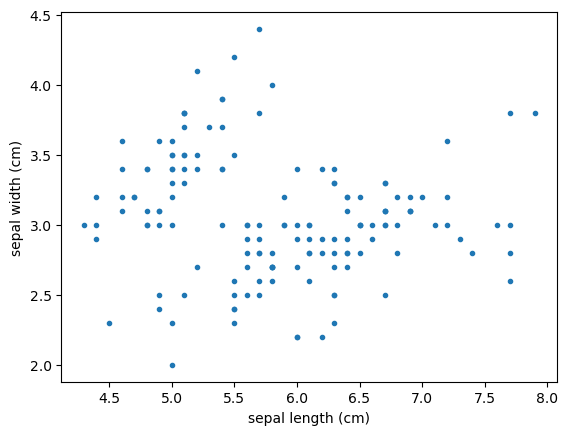

In [14]:
### 
plt.plot(X[:,0],X[:,1],'.')
plt.xlabel('sepal length (cm)')
plt.ylabel("sepal width (cm)")
### 


Text(0, 0.5, 'classes')

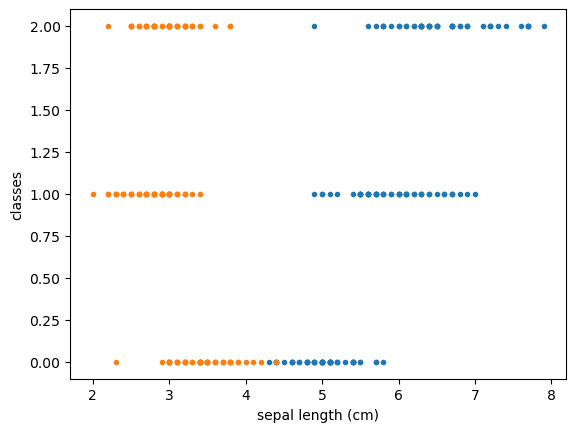

In [15]:
plt.plot(X[:,0],y,'.')
plt.xlabel('sepal length (cm)')
plt.ylabel("classes")
plt.plot(X[:,1],y,'.')
plt.xlabel('sepal length (cm)')
plt.ylabel("classes")


### 数据分解


- 分解占比
    - 训练集（占比 75%） training set
    - 测试集（占比 25%） testing set


- 调用函数 `train_test_split`


- 语法
```python
>>> train_test_split(*arrays, **options)
```


- 功能 —— 分解数据集成 训练集 测试集 两部分


- 参数
    - \*arrays —— 特征数据，目标数据
    - \*\*options —— 关键字
        - test_size 测试集的占比
        - random_state 随机种子

In [16]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [17]:
# 分解成训练集和测试集
# 测试集随机取 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=53)
print (X_train.shape, y_train.shape)
y_train

(112, 2) (112,)


array([1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 2,
       2, 0, 0, 2, 1, 1, 0, 1, 2, 1, 0, 0, 0, 1, 2, 0, 0, 2, 0, 2, 0, 1,
       1, 2, 0, 1, 1, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 0, 1, 2, 0, 1, 1,
       1, 0, 1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1,
       1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 2, 1, 2,
       0, 0])

### 数据预处理


- 标准化
    - 每个数值减平均值 $mean$，然后除以标准差 $std$

$$X' = \dfrac{X-mean}{std}$$


- 目的
    - 规范化数据
    - 避免权重过大 


- 标准化数据，满足
    - 分布不变
    - 0 均值
    - 1 标准差

In [18]:
# 导入标准化函数
from sklearn.preprocessing import StandardScaler

StandardScaler介绍
- 计算训练集的平均值和标准差，以便测试数据集使用相同的变换
- 通过删除平均值和缩放到单位方差来标准化特征

In [ ]:
# 关于StandardScaler的例子
data = [[0, 0], [0, 0], [1, 1], [1, 1]]
data
scaler1 = StandardScaler()
print(scaler1.fit(data))
data
print(scaler1.mean_) #输出平均值
data_tr = scaler1.transform(data)
print(data_tr)
print(scaler1.transform([[2, 2]]))
scaler1.inverse_transform(data_tr)


StandardScaler介绍 - 方法  

|方法名称 | 方法作用   |  
|-|-|
|`fit(X[, y])`	 | Compute the mean and std to be used for later scaling.<br>  计算用于以后缩放的mean和std|
|`fit_transform(X[, y])`	| Fit to data, then transform it. <br>适合数据，然后转换它|
|`get_params([deep])`	|Get parameters for this estimator.|
|`inverse_transform(X[, copy])`	|Scale back the data to the original representation|
|`partial_fit(X[, y])`	|Online computation of mean and std on X for later scaling.|
|`set_params(**params)`	|Set the parameters of this estimator.|
|`transform(X[, y, copy])`	|Perform standardization by centering and scaling <br>通过居中和缩放执行标准|

In [ ]:
#dir(StandardScaler)
# 言归正传


In [19]:
# 特征标准化
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_train

array([[ 0.50463867, -0.40780993],
       [ 0.50463867,  0.69544399],
       [ 0.62940585, -1.29041308],
       [-1.11733463, -0.18715915],
       [-1.11733463, -1.51106386],
       [ 1.37800891,  0.03349164],
       [ 0.37987149, -1.06976229],
       [-0.99256745, -2.393667  ],
       [-0.86780028,  1.57804714],
       [-0.49349874, -0.18715915],
       [ 0.25510432, -0.18715915],
       [-1.74117052,  0.25414242],
       [-1.24210181,  0.03349164],
       [-0.49349874,  0.69544399],
       [-0.99256745,  0.69544399],
       [-1.11733463,  0.03349164],
       [ 0.62940585, -0.62846072],
       [ 2.62568068,  1.57804714],
       [ 0.37987149, -0.62846072],
       [-0.49349874,  1.79869792],
       [-0.86780028,  0.69544399],
       [ 0.13033714, -0.18715915],
       [ 1.25324173, -0.18715915],
       [-0.99256745,  1.13674556],
       [-0.86780028,  1.57804714],
       [ 0.75417303,  0.25414242],
       [ 0.25510432, -1.95236543],
       [-0.86780028, -1.29041308],
       [-0.7430331 ,

### 可视化数据


- 利用 Matplotlib.pyplot 子模块
    - scatter 函数 （画散点图）

Text(0, 0.5, 'Sepal width')

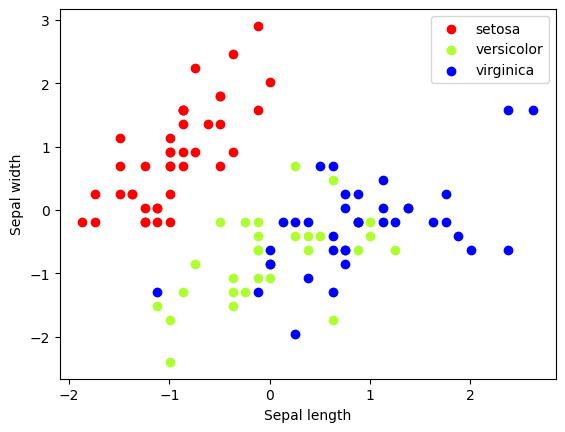

In [20]:
colors = ['red', 'greenyellow', 'blue']
for i in range(len(colors)):
    px = X_train[:, 0][y_train == i]
    py = X_train[:, 1][y_train == i]
    plt.scatter(px, py, c=colors[i])

plt.legend(iris.target_names)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

- 观察发现
    - 山鸢尾花 最容易区分
    - 变色鸢尾花和维吉利亚鸢尾花混在一起

### 4.2.3 分类识别训练（SGD）训练

#### 基于 SGD 的分类器下降法的分类识别训练


#### (1) 方法与分类器介绍


- 随机梯度下降法 —— SGD, Stochastic Gradient Descent
    - 一种寻找函数的局部最小值方法，比较著名
    - 对于本例：算法通过最小化损失函数，<font color="red">学习超平面的系数</font>
<img src="images\ch13\lossfunc.png" width = 400>

- SGDClassifier 分类器
    - 分类器（Classifier）的一种、基于随机梯度下降（Stochastic Gradient Descent）算法


In [ ]:
# 创建对象 线性模型分类器 linear model classifier
from sklearn.linear_model import SGDClassifier
clf = SGDClassifier()

In [ ]:
# ========== Handwritten Gradient Descent Demo ==========
# Goal: find min of f(w) = w^2 using gradient descent (answer: w = 0)
import numpy as np
import matplotlib.pyplot as plt

# Define loss function and its gradient
def f(w):
    return w ** 2

def gradient(w):
    return 2 * w                    # df/dw = 2w

# Gradient descent parameters
w = 4.0                             # Initial guess (far from optimum 0)
lr = 0.1                            # Learning rate
steps = 20                          # Number of iterations

# Record history
history_w = [w]
history_f = [f(w)]

print("Step |   w    |  f(w)=w^2")
print("-" * 28)
print(f"  0  | {w:5.2f}  | {f(w):8.2f}")

for t in range(steps):
    grad = gradient(w)              # Compute gradient
    w = w - lr * grad               # Update: w = w - lr * grad
    history_w.append(w)
    history_f.append(f(w))
    if t < 5 or t > steps - 3:
        print(f" {t+1:2d}  | {w:5.2f}  | {f(w):8.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: parameter w convergence
ax1.plot(history_w, 'o-', markersize=5, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', label='Optimal w=0')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Parameter w')
ax1.set_title(f'Gradient Descent Convergence (lr={lr})')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: loss function descent
ax2.plot(history_f, 'o-', markersize=5, color='darkorange')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss f(w) = w^2')
ax2.set_title('Loss Function Curve')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**▶ 直观理解：**

```mermaid
flowchart TD
    A["🎯 随机初始位置 参数 w = w₀"] --> B["📐 计算梯度 ∇L = ∂Loss/∂w"]
    B --> C["👣 沿梯度反方向更新 w_new = w_old - η × ∇L"]
    C --> D{"收敛? 梯度 ≈ 0"}
    D -->|否| B
    D -->|是| E["✅ 找到最优参数"]
```

**数学公式**（以一维为例）：

$$w_{t+1} = w_t - \eta \cdot \frac{\partial L(w_t)}{\partial w}$$

- $w_t$：第 t 步参数
- $\eta$（学习率）：控制步长
- $\frac{\partial L}{\partial w}$：损失函数的梯度

> 💡 梯度告诉你"往哪走"，学习率告诉你"走多大步"。学习率太大→震荡，太小→太慢。

**下面用 Python 演示**：求 $f(w)=w^2$ 的最小值（已知答案是 $w=0$）。

In [ ]:
# ========== Animated Gradient Descent on f(w)=w^2 ==========
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# ---- Run gradient descent ----
def f(w):      return w ** 2
def grad(w):   return 2 * w

w_start = 4.0
lr = 0.1
steps = 20

w_hist = [w_start]
for _ in range(steps):
    w_hist.append(w_hist[-1] - lr * grad(w_hist[-1]))

# ---- Create animation ----
fig, ax = plt.subplots(figsize=(8, 5))
w_curve = np.linspace(-5, 5, 300)

def draw_frame(i):
    ax.clear()
    w_cur = w_hist[i]
    f_cur = f(w_cur)
    g_cur = grad(w_cur)

    # Parabola
    ax.plot(w_curve, f(w_curve), 'b-', linewidth=2, alpha=0.35)
    # Optimal point
    ax.plot(0, 0, 'r*', markersize=15, zorder=5, label='Optimum w=0')

    # Current point
    ax.plot(w_cur, f_cur, 'o', color='darkorange', markersize=12, zorder=5)

    # Tangent line
    tan_x = np.linspace(w_cur - 1.8, w_cur + 1.8, 50)
    tan_y = f_cur + g_cur * (tan_x - w_cur)
    ax.plot(tan_x, tan_y, 'r--', linewidth=1.5, alpha=0.7, label='Tangent (gradient)')

    # Gradient direction arrow (steepest ascent direction)
    arrow_dx = 0.4 if g_cur > 0 else -0.4
    ax.annotate('', xy=(w_cur + arrow_dx, f(w_cur + arrow_dx)),
                xytext=(w_cur, f_cur),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))

    # Vertical dashed to curve
    ax.vlines(w_cur, 0, f_cur, colors='gray', linestyles='dotted', alpha=0.5)

    # Info box
    info = f'Step {i:2d}\nw = {w_cur:+.4f}\nf(w) = {f_cur:.4f}\ngrad = {g_cur:+.4f}'
    ax.text(0.98, 0.95, info, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))

    ax.set_xlim(-5, 5)
    ax.set_ylim(-1, 20)
    ax.set_xlabel('Parameter w')
    ax.set_ylabel('Loss f(w)')
    ax.set_title(f'Gradient Descent Animation  |  lr={lr}  |  Step {i}/{steps}')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

anim = FuncAnimation(fig, draw_frame, frames=len(w_hist),
                     interval=400, repeat=True)

# Save as GIF and display
gif_path = 'images/ch13/gradient_descent_anim.gif'
import os
os.makedirs('images/ch13', exist_ok=True)
anim.save(gif_path, writer=PillowWriter(fps=3))
plt.close()
print(f'Animation saved to: {gif_path}')
display(Image(filename=gif_path))


#### (3) 分类器之成员函数 `fit`


- 语法
```python
>>> clf.fit(X_train, y_train)
```


- 功能
    - 基于训练数据训练模型
    - 创建超平面

In [ ]:
# 拟合（训练）分类器
clf.fit(X_train, y_train) # 注意参数设置警告

In [ ]:
clf.fit??

#### 训练成果及可视化 及 可视化展示


- 学习效果
    - 系数数组 coef_  $\quad(c_1,c_2,\cdots)$
    - 截距数组 intercept_ $p$


- 分界线方程 —— 超平面方程 $\quad c_1f_1+c_2f_2 + \cdots = p$
     - $c_1,\,c_2,\,\cdots$ 系数
     - $f_1,\,f_2,\,\cdots$ 特征值
     - $p$ 右端项


- 三次二元识别
    - 将得到三组系数和截距

In [ ]:
# 输出 学习得到的系数
print (clf.coef_)
print (clf.intercept_)

- 可视化展示
    - 画出三条决策曲线
    - 效果
        - 类别 1 可以直线分开
        - 类另 2 和 3 不能分开

In [ ]:
x_min, x_max = X_train[:, 0].min() - .5, X_train[:, 0].max() + .5 # 找出最大最小值，用于画图
y_min, y_max = X_train[:, 1].min() - .5, X_train[:, 1].max() + .5
xs = np.arange(x_min,x_max,0.5) #xs数据（绘制直线用）
fig, axes = plt.subplots(1,3)  #三个图
fig.set_size_inches(10,6)  #设置图大小
for i in [0,1,2]:  #按图循环
    axes[i].set_aspect('equal')
    axes[i].set_title('Class ' + str(i) + ' versus the rest')
    axes[i].set_xlabel('Sepal length')
    axes[i].set_ylabel('Sepal width')
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    plt.sca(axes[i])  #指定绘图的当前轴
    for j in range(len(colors)):
        px = X_train[:, 0][y_train == j]
        py = X_train[:, 1][y_train == j]
        plt.scatter(px, py, c=colors[j])
    ys = (-clf.intercept_[i]-xs*clf.coef_[i,0])/clf.coef_[i,1]  #ys数据（绘制直线用）
    plt.plot(xs,ys);#,hold=True)

#### 预测新数据新数据

- 假设新数据（萼片的长度、宽度）为
    - [4.7,3.1]


- 操作过程
    - 同样的数据预处理
    - 三次二元分类识别
    - 输出结果

In [ ]:
# 新数据
new_data = [4.7, 3.1]
new_data

In [ ]:
# 预处理
pre_process_data = scaler.transform([new_data])
pre_process_data
# 类型预测 0-setosa, 1-versicolor, 2-virginica
print (clf.predict(pre_process_data))
# 三个决策函数值筛选 —— 取最大值对应的类别
print(clf.decision_function(pre_process_data))


### 4.2.4 检验模型效果的效果

### 准确率评估 `metrics`

In [ ]:
from sklearn import metrics

### 对比目标值


- 调用函数
```python
>>> metrics.accuracy_score(y_train, y_train_pred)
```


- 参数
    - y_train 人工结果值
    - y_train_pred 预测值


- 返回值
    - score —— 分数介于 0 和 1 之间

In [ ]:
# 根据模型得到的预测值
y_train_pred = clf.predict(X_train)

# 与人工值比较，并输出得分
train_score = metrics.accuracy_score(y_train, y_train_pred)
train_score

### 用测试集检验

In [ ]:
# 测试集也要标准化
X_test = scaler.transform(X_test)

# 预测
y_pred = clf.predict(X_test)

# 与人工值比较，并输出得分
test_score = metrics.accuracy_score(y_test, y_pred)
test_score

### 4.2.5 进一步分析与优化分析

### 发现问题

- 训练集的分数比测试集更好！
    - $test\_score < train\_score$
- 为什么？
    - 合理而常见

### 更多检验指标

- 分类准确率分数是指所有分类正确的百分比。分类准确率这一衡量分类器的标准比较容易理解，但是它不能告诉你响应值的潜在分布，并且它也不能告诉你分类器犯错的类型。


- Precision
- Recall
- F-score
- 混淆矩阵 （the confusion matrix）

In [ ]:
print (metrics.classification_report(y_test, y_pred, target_names=iris.target_names, zero_division=1))

In [ ]:
print (metrics.confusion_matrix(y_test, y_pred))

- 准确率（正确率）=所有预测正确的样本/总的样本  （TP+TN）/总 [对角线]

- 精确率=  将正类预测为正类 / 所有预测为正类 TP/（TP+FP）[竖着看]

- 召回率 = 将正类预测为正类 / 所有正真的正类 TP/（TP+FN）[横着看]

- F值 = 精确率 * 召回率 * 2 / (正确率 + 召回率) （F 值即为精确率和召回率的调和平均值）


### 混淆矩阵也称误差矩阵
<img src='images\ch13\ch13-04.jpg' width=300><img src='images\ch13\ch13-03.jpg' width=300>
- 精确率_类别1：$\frac{a}{a+d+g}$ 识别成某个类别中真正是该类的比率
- 召回率_类别1：$\frac{a}{a+b+c}$ 原先某个类别被识别正确的比率

### K-折交叉检验与 Pipeline


- 创建一个新的分类器
    - 将数据集切分成 $k$ 部分
    - 取其中 $k-1$ 块进行训练
    - 取剩下的一块用来测试评估
    - 进行 $k$ 次，取平均得分


- pipeline （管道或管线），连接
    - 标准化器
    - 线性模型 —— 随机梯度下降分类器


- 交叉检验精度 —— 对每一折

<img src='images\ch13\ch13-05.jpg'>

#### (1) 流程更简洁

In [ ]:
# 导入函数等
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

### scikit_learn里的 pipeline
- pipeline 实现了对全部步骤的流式化封装和管理，可以很方便地使参数集在新数据集上被重复使用。
- pipeline 可以用于下面几处：
    - 模块化 Feature Transform，只需写很少的代码就能将新的 Feature 更新到训练集中。  
    - 自动化 Grid Search，只要预先设定好使用的 Model 和参数的候选，就能自动搜索并记录最佳的 Model。  
    - 自动化 Ensemble Generation，每隔一段时间将现有最好的 K 个 Model 拿来做 Ensemble。  
    - 要用 Pipeline 对训练集和测试集进行如下操作：
        - 先用 StandardScaler 对数据集每一列做标准化处理，（是 transformer）
        - 再用 PCA 将原始的 30 维度特征压缩的 2 维度，（是 transformer）
        - 最后再用模型 LogisticRegression。（是 Estimator）
        - 调用 Pipeline 时，输入由元组构成的列表，每个元组第一个值为变量名，元组第二个元素是 sklearn 中的 transformer 或 Estimator。
        - 注意中间每一步是 transformer，即它们必须包含 fit 和 transform 方法，或者 fit_transform。
        - 最后一步是一个 Estimator，即最后一步模型要有 fit 方法，可以没有 transform 方法。
    - Pipeline对象接受二元tuple构成的list，每一个二元 tuple 中的第一个元素为 arbitrary identifier string，我们用以获取（access）Pipeline object 中的 individual elements，二元 tuple 中的第二个元素是 scikit-learn与之相适配的transformer 或者 estimator。  
<img src='images\ch13\sklearn_pipeline.png' width=450>

In [ ]:
# 创建管线实现的复合估计器
clf = Pipeline([('scaler', StandardScaler()),
                ('linear_model', SGDClassifier())])
clf
# 创建 k-折交叉验证迭代器，取 k=5
# cv = KFold(X.shape[0], 5, shuffle=True, random_state=33)
cv = KFold(5, shuffle=True, random_state=33)
#KFold?
cv
# 得分
cross_scores = cross_val_score(clf, X, y, cv=cv)  
print(cross_scores)
#cross_val_score??


#### (2) 交叉验证精度的均值和标准差

In [ ]:
from scipy.stats import sem

def mean_score(scores):
    """Print the empirical mean score and standard error of the mean."""
    return ("Mean score: {0:.3f} (+/-{1:.3f})").format(
        np.mean(scores), sem(scores))

print(mean_score(cross_scores))

### 4.2.6 知识梳理

- 主要流程
    - 初识问题数据 —— 加载、观察、初步统计分析等
    - 数据准备
        - 导入特征、目标数据
        - 选取重要特征 （重要环节）
        - 数据分解
        - 数据预处理
        - 数据可视化
    - 分类识别训练
        - 选取方法与分类器
        - 创建分类器对象
        - 训练拟合 fit
        - 检验训练成果
        - 预测新数据
    - 检验模型的效果
        - 训练集检验
        - 测试集检验
    - 进一步分析
        - 发现问题
        - 改进方法
            - 调整参数
            - 选择其它方法
            - 属性重新组合
            - 等

In [ ]:
# 大家尝试用另外两个属性进行分类？
# 并反馈平均得分


## 4.3  其他类似例子

In [ ]:
import pandas as pd
import numpy as np

# features column names
column_names = ['Sample code number','Clump Thickness','Uniformity of Cell Size' ,'Uniformity of Cell Shape','Marginal Adhesion',
'Single Epithelial Cell Size','Bare Nuclei','Bland Chromatin','Normal Nucleoli','Mitoses','Class']

#read data from csv file
##data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data',names=column_names)
data = pd.read_csv('data/breast-cancer-wisconsin.data',names=column_names)
#data = pd.read_csv('data/breast-cancer-wisconsin.data',names=column_names)

<img src='images\ch13\ch13-06.jpg' width =500>

https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

In [ ]:
data.head()

In [ ]:
data.tail()

In [ ]:
data.describe()

In [ ]:
#Data preprocessing
#replace all ? with standard missing value

data = data.replace(to_replace='?',value=np.nan)

#drop all data rows which have any missing feature
data=data.dropna(how='any')

# data.to_csv('data\text.csv')# save data to csv file

In [ ]:
data.describe()

In [ ]:
#notes:you should use cross_valiation instead of model_valiation in python 2.7

#from sklearn.cross_validation import train_test_split #DeprecationWarning

from sklearn.model_selection import train_test_split #use train_test_split module of sklearn.model_valiation to split data

In [ ]:
#take 25 percent of data randomly for testing,and others for training

X_train,X_test,y_train,y_test = train_test_split(data[column_names[1:10]],
                                                 data[column_names[10]],
                                                 test_size=0.25,random_state=33)

#check the numbers and category distribution of the test samples
# print(y_train.value_counts())
# print(y_test.value_counts())

#import relative package
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

#standardizing data in train set and test set
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

#sgdcclassifier model
#sgdc=SGDClassifier() #DeprecationWarning

sgdc=SGDClassifier(max_iter=5,tol=None)

#call fit function to trainning arguments ofmodel
sgdc.fit(X_train,y_train)

sgdc_y_predict=sgdc.predict(X_test)
sgdc_y_predict
data[column_names[10]]
#performance analysis
from sklearn.metrics import classification_report

#get accuracy by the score function in SGD classifier
print('Accuracy of SGD Classifier:',sgdc.score(X_test,y_test))

#get  precision ,recall and f1-score from classification_report module
print(classification_report(y_test,sgdc_y_predict,target_names=['Benign','Malignant']))
# 导入函数等
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
# 创建管线实现的复合估计器
clf = Pipeline([
        ('scaler', StandardScaler()),
        ('linear_model', SGDClassifier())
])
X, y = data[column_names[1:10]], data[column_names[10]]
# 创建 k-折交叉验证迭代器，取 k=5
#cv = KFold(X.shape[0], 5, shuffle=True, random_state=33)
cv = KFold(5, shuffle=True, random_state=33)
cv
# 得分
cross_scores = cross_val_score(clf, X, y, cv=cv)  #检查数据是否有缺失？
print(cross_scores)
from scipy.stats import sem

def mean_score(scores):
    """Print the empirical mean score and standard error of the mean."""
    return ("Mean score: {0:.3f} (+/-{1:.3f})").format(
        np.mean(scores), sem(scores))

print(mean_score(cross_scores))


# 葡萄酒分类！
<img src='images\ch13\ch13-08.png' width =500>

In [ ]:
# 练习！
#https://archive.ics.uci.edu/ml/datasets/Wine
column_names  = ["class", "Alcohol", "Malic acid", "Ash", "Alcalinity of ash", "Magnesium", "Total phenols", "Flavanoids", "Nonflavanoid phenols", "Proanthocyanins", "Color intensity", "Hue", "OD280/OD315 of diluted wines", "Proline"]
#data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data',names=column_names)
data = pd.read_csv('data/wine.data',names=column_names)

<img src='images\ch13\ch13-07.png' width =500>

In [ ]:
data.tail()

In [ ]:
# 请用本堂课的知识，建立一个分类器


## 4.4 拓展：TensorFlow 实现鸢尾花的随机梯度下降分类

前面我们使用 scikit-learn 的 `SGDClassifier` 完成了鸢尾花识别。**TensorFlow**（通过 Keras 高层 API）同样支持随机梯度下降，而且可以直观地画出损失函数随迭代的下降曲线。

本部分的**学习路径**与 4.2 节 sklearn 版一一对应：

```mermaid
flowchart LR
    A["1️⃣ 认识工具\nTensorFlow / Keras"] --> B["2️⃣ 数据准备\n标准化 + one-hot"]
    B --> C["3️⃣ 构建模型\n4 → 16 → 3 网络"]
    C --> D["4️⃣ 编译 + 训练\nSGD · 100 轮"]
    D --> E["5️⃣ 评估对比\n准确率 / 损失曲线"]
```

> 💡 **梯度下降的三种形态**

| 名称 | batch_size | 特点 |
|------|-----------|------|
| 批量梯度下降（BGD） | 全部样本 | 梯度最平稳，但每步计算量大 |
| **随机梯度下降（SGD）** | 1 | 每次只用 1 个样本，损失曲线抖动大 |
| 小批量梯度下降（Mini-batch） | 32 / 64 等 | 实践中最常用，兼顾效率与稳定性 |

> 📦 环境准备：`pip install tensorflow`（CPU 版即可，无需 GPU）

### 4.4.1 认识 TensorFlow

**TensorFlow** 是 Google 开源的端到端机器学习平台。"Tensor"（张量）+"Flow"（流动），寓意数据以张量的形式在计算图中流动。

| 项目 | 说明 |
|------|------|
| 开发者 | Google Brain 团队 |
| 首次发布 | 2015 年 11 月 |
| 定位 | 工业级部署，跨平台（服务器 / 移动端 / 浏览器） |
| 高层 API | **Keras**（tf.keras）—— 简洁易用，本讲使用它 |
| 底层能力 | 自动微分（GradientTape）、GPU / TPU 加速 |
| 官网 | [tensorflow.org](https://www.tensorflow.org/) |

**TensorFlow 与 scikit-learn 的分工**

| 对比项 | scikit-learn | TensorFlow (Keras) |
|--------|--------------|--------------------|
| 强项 | 传统机器学习：分类 / 回归 / 聚类 | 深度学习：神经网络 |
| 资源需求 | 轻量，CPU 即可 | 大模型建议 GPU，小模型 CPU 也很快 |
| 学习成本 | 低，API 统一 | 稍高，概念更多 |
| 本讲用法 | `SGDClassifier` | `optimizer='SGD'` |

**四个核心概念**

- **张量 Tensor** —— 多维数组，可类比 NumPy 的 ndarray
- **层 Layer** —— 神经网络的基本构件（如全连接层 `Dense`）
- **模型 Model** —— 由若干层堆叠而成（如 `Sequential` 顺序模型）
- **优化器 Optimizer** —— 本讲的 SGD 就是其中一种，另有 Adam、Momentum 等

#### 什么是张量（Tensor）？

**张量 = 多维数组**，由"阶（rank）"描述其维度个数。深度学习框架中的数据，一律用张量表示：

| 阶 | 名称 | 生活例子 | 形状 shape |
|----|------|----------|-----------|
| 0 | 标量 Scalar | 温度 36.5°C | `()` |
| 1 | 向量 Vector | 一朵花的 4 个特征 | `(4,)` |
| 2 | 矩阵 Matrix | 一张灰度图片 | `(28, 28)` |
| 3 | 3 阶张量 | 一张彩色图片（高 × 宽 × RGB 三通道） | `(28, 28, 3)` |
| 4 | 4 阶张量 | 一小段视频（帧 × 高 × 宽 × 通道） | `(100, 28, 28, 3)` |

> 💡 **记忆口诀**：标量是"点"，向量是"线"，矩阵是"面"，3 阶是"一摞纸"，4 阶及以上是"一柜子文件"。

下面的代码把 0～3 阶张量画成直观图形：

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 设置中文字体，避免标题出现乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))

# ---- 0 阶张量：标量（一个点） ----
ax = axes[0]
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.plot(0, 0, 'o', markersize=35, color='steelblue')
ax.set_title('0 阶张量：标量\n例：温度 36.5°C', fontsize=11)
ax.axis('off')

# ---- 1 阶张量：向量（一行格子） ----
ax = axes[1]
n = 5
for i in range(n):
    ax.add_patch(Rectangle((i, 0), 0.85, 0.85, facecolor='#a6cee3',
                           edgecolor='steelblue', lw=1.5))
    ax.text(i + 0.425, 0.425, str(i), ha='center', va='center', fontsize=10)
ax.set_xlim(-0.4, n * 0.95 + 0.2); ax.set_ylim(-0.5, 1.3)
ax.set_title('1 阶张量：向量\n例：一个样本的 4 个特征', fontsize=11)
ax.axis('off')

# ---- 2 阶张量：矩阵（一个二维网格） ----
ax = axes[2]
r, c = 4, 4
for i in range(r):
    for j in range(c):
        ax.add_patch(Rectangle((j, r - 1 - i), 0.85, 0.85, facecolor='#b2df8a',
                               edgecolor='#33a02c', lw=1.5))
ax.set_xlim(-0.4, c * 0.95 + 0.2); ax.set_ylim(-0.4, r * 0.95 + 0.2)
ax.set_title('2 阶张量：矩阵\n例：一张灰度图片', fontsize=11)
ax.axis('off')

# ---- 3 阶张量：多个矩阵堆叠 ----
ax = axes[3]
d, r, c = 3, 4, 4
colors = ['#fb9a99', '#fdbf6f', '#cab2d6']
for k in range(d):
    offx, offy = k * 0.25, k * 0.25
    for i in range(r):
        for j in range(c):
            ax.add_patch(Rectangle((j + offx, r - 1 - i + offy), 0.8, 0.8,
                                   facecolor=colors[k], edgecolor='gray',
                                   lw=1, alpha=0.85))
ax.set_xlim(-0.4, c * 0.95 + d * 0.35); ax.set_ylim(-0.4, r * 0.95 + d * 0.35)
ax.set_title('3 阶张量：矩阵堆叠\n例：彩色图片 (高×宽×RGB)', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 动手验证：TensorFlow 中创建不同阶的张量
import tensorflow as tf

scalar = tf.constant(36.5)                 # 0 阶：标量
vector = tf.constant([1.0, 2.0, 3.0, 4.0]) # 1 阶：向量（4 个特征）
matrix = tf.ones([2, 3])                   # 2 阶：矩阵（2 行 3 列）
tensor3 = tf.zeros([2, 3, 4])              # 3 阶：张量

print("标量  shape:", scalar.shape, "  阶数:", scalar.ndim)
print("向量  shape:", vector.shape, "  阶数:", vector.ndim)
print("矩阵  shape:", matrix.shape, "  阶数:", matrix.ndim)
print("3阶张量 shape:", tensor3.shape, "  阶数:", tensor3.ndim)

### 4.4.2 数据准备

与 4.2 节 sklearn 版基本一致的四个步骤。

唯一的区别是**标签编码**：神经网络输出层用 Softmax 输出 3 个概率，所以标签要变成独热（one-hot）编码。

| 步骤 | 做法 | 与 sklearn 版对比 |
|------|------|-------------------|
| 1. 加载 | `load_iris()` | 相同 |
| 2. 标准化 | `StandardScaler` | 相同 |
| 3. 标签编码 | `to_categorical` →<br> one-hot，如 `2 → [0, 0, 1]` | 不同（sklearn 直接用 0/1/2） |
| 4. 划分 | `train_test_split(test_size=0.2)` | 相同（sklearn 版取 0.25） |

> 💡 独热编码：把"第几类"变成一串 0/1，长度 = 类别数，只有真实类别那一位是 1。这样正好能和 Softmax 输出的概率逐位比较。

In [ ]:
# 导入库
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# 固定随机种子，保证结果可复现
np.random.seed(42)
tf.random.set_seed(42)

# 1. 加载鸢尾花数据
iris = load_iris()
X = iris.data        # 特征 (150, 4)
y = iris.target      # 标签 0 / 1 / 2

# 2. 特征标准化 + 标签独热（one-hot）编码
X = StandardScaler().fit_transform(X)
y = to_categorical(y, num_classes=3)

# 3. 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("训练集:", X_train.shape, y_train.shape)
print("测试集:", X_test.shape, y_test.shape)

### 4.4.3 构建模型并训练

网络结构：**输入层(4 个特征) → 全连接隐藏层(16 个神经元, ReLU) → 输出层(3 类, Softmax)**。

优化器选择 `tf.keras.optimizers.SGD`，即随机梯度下降。

下图直观展示这个"4 → 16 → 3"的网络结构（可对照下方 `model.summary()` 输出的参数量）：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 6))

# 三层神经元的位置
ys_in  = np.linspace(0.75, 0.15, 4)   # 输入层 4 个
ys_hid = np.linspace(0.85, 0.05, 16)  # 隐藏层 16 个
ys_out = np.linspace(0.65, 0.25, 3)   # 输出层 3 个

# 全连接线：输入层 → 隐藏层 → 输出层
for yi in ys_in:
    for yh in ys_hid:
        ax.plot([0, 1], [yi, yh], color='lightgray', lw=0.5, zorder=1)
for yh in ys_hid:
    for yo in ys_out:
        ax.plot([1, 2], [yh, yo], color='lightgray', lw=0.5, zorder=1)

# 画神经元
ax.scatter([0]*4,  ys_in,  s=900, color='#a6cee3', edgecolors='k', linewidths=1.2, zorder=2)
ax.scatter([1]*16, ys_hid, s=900, color='#fdbf6f', edgecolors='k', linewidths=1.2, zorder=2)
ax.scatter([2]*3,  ys_out, s=900, color='#b2df8a', edgecolors='k', linewidths=1.2, zorder=2)

# 层标题
ax.text(0, 1.05, '输入层\n4 个特征', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(1, 1.05, '隐藏层（全连接）\n16 个神经元 · ReLU', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(2, 1.05, '输出层\n3 类 · Softmax', ha='center', va='center', fontsize=11, fontweight='bold')

# 参数量说明
ax.text(0.5, -0.18, '参数 4×16 + 16 = 80', ha='center', fontsize=10, color='dimgray')
ax.text(1.5, -0.18, '参数 16×3 + 3 = 51', ha='center', fontsize=10, color='dimgray')

# 输入特征名称
for y, t in zip(ys_in, ['萼片长度', '萼片宽度', '花瓣长度', '花瓣宽度']):
    ax.text(-0.28, y, t, ha='right', va='center', fontsize=10)

# 输出类别名称
for y, t in zip(ys_out, ['setosa\n山鸢尾花', 'versicolor\n变色鸢尾花',
                         'virginica\n维吉尼亚鸢尾花']):
    ax.text(2.28, y, t, ha='left', va='center', fontsize=10)

ax.set_xlim(-1.6, 3.4)
ax.set_ylim(-0.35, 1.28)
ax.set_title('鸢尾花识别神经网络结构图：4 → 16 → 3（总参数 131 个）', fontsize=13)
ax.axis('off')
plt.show()

In [ ]:
# 构建模型：4 个特征输入 → 隐藏层 → 3 类输出
model = tf.keras.Sequential([
    tf.keras.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# 编译：优化器选择 SGD（随机梯度下降）
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

#### 激活函数 ReLU 与 Softmax

上面 `Dense` 层里的 `activation` 参数指定**激活函数**，决定每个神经元"要不要、以多大强度"把信号传给下一层。

**ReLU —— 隐藏层的"阈值开关"**

$$\text{ReLU}(x)=\max(0,\,x)$$

- 输入为负 → 输出 0（神经元"关闭"）
- 输入为正 → 原样输出（神经元"打开"）
- 作用：给网络带来**非线性**。没有它，多层堆叠也只是线性变换，只能画"直线"，学不会复杂规律

**Softmax —— 输出层的"概率换算器"**

$$p_i = \frac{e^{z_i}}{e^{z_1}+e^{z_2}+e^{z_3}}$$

- 把 3 个输出分数变成概率：每个都在 0～1 之间，且相加 = 1
- 概率最大的那一类，就是预测结果
- 作用：三分类问题的标准输出，正好与独热（one-hot）标签匹配

> 🧠 类比：ReLU 像"刺激不够就不响应"的神经开关；Softmax 像期末把三名学生的原始分折算成**总和 100%** 的占比。

下面画出两条函数曲线，并动手算一遍 Softmax：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(-5, 5, 200)
relu = np.maximum(0, x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图：ReLU 函数曲线
ax = axes[0]
ax.plot(x, relu, lw=2.5, color='steelblue', label='ReLU(x) = max(0, x)')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.fill_between(x[x < 0], relu[x < 0], color='lightcoral', alpha=0.3,
                label='负输入 → 输出 0')
ax.set_title('ReLU：负输入被"关闭"为 0')
ax.set_xlabel('输入 x')
ax.set_ylabel('输出 ReLU(x)')
ax.legend()
ax.grid(alpha=0.3)

# 右图：Softmax 把 3 个分数换算成概率
z = np.array([2.0, 1.0, 0.1])     # 假设输出层 3 个原始分数
p = np.exp(z) / np.exp(z).sum()
labels = ['setosa\n分数 2.0', 'versicolor\n分数 1.0', 'virginica\n分数 0.1']
bars = axes[1].bar(labels, p, color=['#a6cee3', '#fdbf6f', '#b2df8a'],
                   edgecolor='k', linewidth=1)
for b, v in zip(bars, p):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.2f}',
                 ha='center', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].set_title('Softmax：分数 → 概率（总和 = 1）')
axes[1].set_ylabel('概率 p')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# 动手算一遍 Softmax
import numpy as np

z = np.array([2.0, 1.0, 0.1])     # 输出层 3 个原始分数
e_z = np.exp(z)                   # 第 1 步：取指数
p = e_z / e_z.sum()               # 第 2 步：除以指数之和

print("原始分数 z :", z)
print("取指数 e^z :", np.round(e_z, 3))
print("概率 p     :", np.round(p, 3))
print("概率之和   :", round(p.sum(), 6))
print("预测类别   :", p.argmax(), "（setosa，概率最大）")

#### 损失函数：交叉熵 Cross-Entropy

`model.compile` 里的 `loss='categorical_crossentropy'` 就是本案例的损失函数——**多分类交叉熵**，用来衡量"模型预测的概率"与"真实标签"差多少。

**公式**（单个样本）：

$$L = -\sum_{c=1}^{3} y_c \cdot \ln(\hat{y}_c)$$

- $\hat{y}_c$：模型预测的第 c 类概率（Softmax 输出）
- $y_c$：真实标签（one-hot，真实类为 1，其余为 0）

由于 one-hot 只有真实那一类为 1，公式实际只剩一项：

$$L = -\ln(\hat{y}_{\text{真实类别}})$$

**直观理解**：只看模型给"真实类别"的那份概率——

- 预测越准（概率 → 1），损失 → 0 ✅
- 预测越差（概率 → 0），损失 → +∞ 💥

> 🧠 类比：老师只看你"标准答案"那一栏的把握程度——你越确信正确答案，扣分越少；你押错了宝，扣分爆炸。

下面画出 $L=-\ln(p)$ 的曲线，并动手算两个例子：

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

p = np.linspace(0.01, 1, 200)     # 模型给"真实类别"的概率（0 ~ 1）
L = -np.log(p)                    # 交叉熵损失

plt.figure(figsize=(7, 4.5))
plt.plot(p, L, lw=2.5, color='tomato')
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('模型给真实类别的概率 p')
plt.ylabel('损失 L = −ln(p)')
plt.title('交叉熵损失：预测越准，损失越小')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 动手算一遍交叉熵损失
import numpy as np

y_true = np.array([0., 1., 0.])        # 真实标签：versicolor（one-hot）
y_pred1 = np.array([0.1, 0.8, 0.1])    # 预测得不错
y_pred2 = np.array([0.8, 0.1, 0.1])    # 预测错了方向

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred))

print("预测1 [0.1, 0.8, 0.1] → 损失:", round(cross_entropy(y_true, y_pred1), 3))
print("预测2 [0.8, 0.1, 0.1] → 损失:", round(cross_entropy(y_true, y_pred2), 3))

# 与 Keras 自带的交叉熵结果对比（两者一致）
import tensorflow as tf
loss_fn = tf.keras.losses.CategoricalCrossentropy()
print("Keras 算预测1:", round(float(loss_fn(y_true, y_pred1).numpy()), 3))
print("Keras 算预测2:", round(float(loss_fn(y_true, y_pred2).numpy()), 3))

#### 优化器在代码中的位置

优化器在代码里出现在**两处：一处"配置"，一处"干活"**。

**① 配置 —— 在上面的 `model.compile()` 中指定**

`optimizer=tf.keras.optimizers.SGD(learning_rate=0.1)` 表示选用**随机梯度下降**优化器，学习率 $\eta=0.1$（对应更新公式 $w = w - \eta\cdot\nabla L$ 里的步长）。想换算法只需改这里，如 `Adam()`、`SGD(momentum=0.9)`。

**② 干活 —— 在下面 `model.fit()` 中被反复调用**

`fit` 每训练一个 batch（`batch_size=32` 条样本），Keras 在后台自动循环三步：

```mermaid
flowchart LR
    A["前向传播\n算预测值 ŷ"] --> B["计算损失 loss\n预测 vs 真实"]
    B --> C["反向传播\n算出梯度 ∇L"]
    C --> D["优化器更新权重\nw = w − η·∇L"]
    D --> A
```

**一句话总结**

| 部件 | 回答的问题 |
|------|-----------|
| 网络结构 `Sequential` | "算什么" |
| 损失函数 `loss` | "错多少" |
| 优化器 `optimizer` | "怎么改"（把梯度翻译成每一次权重更新） |

> 💡 对比 scikit-learn：`SGDClassifier` 的优化器藏在分类器内部，不用单独指定；而 Keras 把优化器做成一个**可单独替换的零件**，在 `compile` 里显式配置。

In [ ]:
# 训练（batch_size=32，即"小批量梯度下降"）
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# 测试集评估
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"测试集损失: {loss:.4f}")
print(f"测试集准确率: {acc:.4f}")

# 打印前 5 个样本的预测类别与真实类别
y_pred = model.predict(X_test, verbose=0)
print("预测类别:", np.argmax(y_pred[:5], axis=1))
print("真实类别:", np.argmax(y_test[:5], axis=1))

### 4.4.4 观察：batch_size 对梯度下降的影响

把 batch_size 分别设为 **1（严格 SGD）**、**32（Mini-batch）**、**全部样本（BGD）**，对比损失曲线的抖动程度。

**先弄懂两个词**

- **batch（批次）** —— 训练时不是把全部样本一次性喂给模型，而是分成一小份一小份地喂，每一小份叫一个 batch
- **batch_size（批次大小）** —— 一个 batch 里装几条样本；模型每看完一个 batch，才更新一次参数

**生活类比：老师改作业**

| batch_size | 类比 | 特点 |
|-----------|------|------|
| 1 | 改完一本，马上根据**这一本**调整教学计划 | 反应快，但容易被个别学生带偏，计划忽左忽右 |
| 32 | 改完一摞（32 本），根据**这一摞的平均情况**调整 | 又快又稳，实践中最常用 |
| 全部样本 | 全部改完，根据**全班平均分**才调整一次 | 最稳，但一次要改很久，调整很慢 |

**为什么 batch_size=1 时损失曲线会"抖动"？**

每个样本算出的"下山方向"（梯度）都略有不同。只根据 1 个样本就更新一次，方向一会儿偏左、一会儿偏右，损失曲线就像喝醉酒走路一样**忽上忽下**；一个 batch 里的样本越多，平均出来的方向越接近真实方向，曲线就越平滑。

In [ ]:
import matplotlib.pyplot as plt

# 设置中文字体，避免标题/图例出现乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 对比三种梯度下降形态的损失曲线
for name, bs in [("SGD (batch=1)", 1),
                 ("Mini-batch (batch=32)", 32),
                 ("BGD (batch=全量)", X_train.shape[0])]:
    m = tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')])
    m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    h = m.fit(X_train, y_train, epochs=100, batch_size=bs,
              validation_split=0.2, verbose=0)
    plt.plot(h.history['loss'], label=name)

plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('不同 batch_size 的损失下降曲线（鸢尾花, SGD）')
plt.legend()
plt.show()

> 💡 **4.4 小结：两种工具殊途同归**
>
> | 对比项 | scikit-learn | TensorFlow (Keras) |
> |--------|--------------|--------------------|
> | 模型 | `SGDClassifier`（线性分类器） | `Sequential` 神经网络（4 → 16 → 3） |
> | 优化器 | 内置在分类器里 | `compile(optimizer='SGD')` 单独配置 |
> | 标签格式 | 0 / 1 / 2 整数 | one-hot 独热编码 |
> | 训练 | `clf.fit(X, y)` | `model.fit(..., epochs, batch_size)` |
> | 观察训练过程 | 系数 `coef_` | 损失曲线 `history` |
>
> - Keras 中 `optimizer='SGD'` 配合 `batch_size` 即可实现三种形态的梯度下降
> - batch_size 越小，损失曲线抖动越大；越大越平稳，但每步计算量也越大
> - 同一份鸢尾花数据，两种工具的分类结果基本一致（准确率 95% 以上）